# Cognifyz Data Science Internship – Level 1: Restaurant Data Analysis

**Author:** Varun  
**Internship Track:** Data Science  
**Organization:** Cognifyz Technologies  
**Project Scope:** Level 1 (Tasks 1, 2, and 3 Complete Implementation)  
**Dataset:** Zomato Global Restaurant Intelligence Dataset (9,551 records, 21 attributes)

## 2. Internship Objective

The primary objective of this project is to execute the complete **Level 1 Data Science Internship Curriculum** for **Cognifyz Technologies**. This project is divided into three comprehensive tasks:

1. **Task 1: Data Exploration and Preprocessing**
   - Ingest the raw restaurant dataset, identify dimensions, inspect data types, and review structural properties.
   - Audit missing values across all columns and implement domain-justified handling strategies.
   - Audit and deduplicate records.
   - Convert data types safely and check for anomalous/suspicious values.
   - Investigate the distribution, zero-inflation, and concentration patterns of the target variable: `Aggregate rating`.
   - Export the cleaned dataset.

2. **Task 2: Descriptive Analysis**
   - Automatically calculate numerical descriptive statistics (mean, median, standard deviation, percentiles).
   - Perform categorical distribution analysis for `Country Code` and `City`.
   - Properly parse and explode multi-valued `Cuisines` strings to accurately evaluate individual cuisine popularity.
   - Formulate business and consumer insights from observed distributions.

3. **Task 3: Geospatial Analysis**
   - Validate geographic coordinates (`Latitude` and `Longitude`) and handle missing/Null Island telemetry.
   - Build a high-performance interactive map with Folium displaying restaurant clusters and rich metadata popups.
   - Analyze spatial distribution patterns across cities and countries.
   - Investigate empirical relationships between location and rating, evaluating Pearson and Spearman correlations.

## 3. Import Libraries

We import essential data science libraries for manipulation, visualization, geospatial mapping, and statistical evaluation.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, FastMarkerCluster

# Suppress minor warnings for clean evaluation presentation
warnings.filterwarnings('ignore')

# Visual styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("All libraries imported successfully!")
print(f"Pandas Version    : {pd.__version__}")
print(f"NumPy Version     : {np.__version__}")
print(f"Folium Version    : {folium.__version__}")

All libraries imported successfully!
Pandas Version    : 3.0.5
NumPy Version     : 2.5.3
Folium Version    : 0.20.0


## 4. Load Dataset

We load the actual dataset from `../data/dataset.csv` (or `data/dataset.csv`). The data file contains UTF-8 BOM characters, which we safely handle using `encoding='utf-8-sig'`.

In [2]:
# Locate and load the dataset safely
possible_paths = [
    os.path.join('..', 'data', 'dataset.csv'),
    os.path.join('data', 'dataset.csv'),
    'dataset.csv'
]

dataset_path = None
for p in possible_paths:
    if os.path.exists(p):
        dataset_path = p
        break

if not dataset_path:
    raise FileNotFoundError("Could not find dataset.csv. Please ensure it is present in data/.")

df_raw = pd.read_csv(dataset_path, encoding='utf-8-sig')
# Clean whitespace in headers
df_raw.columns = [c.strip() for c in df_raw.columns]

print(f"Loaded dataset from: {dataset_path}")
print(f"Initial Shape: {df_raw.shape[0]:,} rows by {df_raw.shape[1]} columns")

Loaded dataset from: data\dataset.csv
Initial Shape: 9,551 rows by 21 columns


## 5. Dataset Overview

Let us examine the basic dataset structure: row/column counts, column names, data types, non-null counts, and the first and last 5 observations.

In [3]:
print("=" * 75)
print("DATASET OVERVIEW & STRUCTURAL INTEGRITY")
print("=" * 75)
print(f"Total Rows    : {df_raw.shape[0]:,}")
print(f"Total Columns : {df_raw.shape[1]}")

print("\nFeature Inventory & Types:")
col_overview = pd.DataFrame({
    'Column Name': df_raw.columns,
    'Data Type': df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count': df_raw.isnull().sum().values
})
display(col_overview)

print("\nFirst 5 Rows (Head):")
display(df_raw.head(5))

print("\nLast 5 Rows (Tail):")
display(df_raw.tail(5))

DATASET OVERVIEW & STRUCTURAL INTEGRITY
Total Rows    : 9,551
Total Columns : 21

Feature Inventory & Types:


,Column Name,Data Type,Non-Null Count,Null Count
0,Restaurant ID,int64,9551,0
1,Restaurant Name,str,9551,0
2,Country Code,int64,9551,0
3,City,str,9551,0
4,Address,str,9551,0
5,Locality,str,9551,0
6,Locality Verbose,str,9551,0
7,Longitude,float64,9551,0
8,Latitude,float64,9551,0
9,Cuisines,str,9542,9



First 5 Rows (Head):


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229



Last 5 Rows (Tail):


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


## 6. Task 1 — Data Exploration and Preprocessing

In this section, we implement the complete requirements of **Task 1**:
- Complete missing-value report across every column.
- Strategy-driven missing value handling.
- Duplicate detection and removal.
- Safe data type conversions.
- Anomalous and suspicious value validation.
- Target variable distribution and concentration analysis.
- Saving the cleaned dataset.

### 7. Missing Value Analysis & Strategy-Driven Imputation

We systematically check for missing values in every column and generate a detailed audit table showing missing counts and percentages.

In [4]:
# Missing value audit
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

missing_report = pd.DataFrame({
    'Column Name': df_raw.columns,
    'Missing Count': missing_count.values,
    'Missing Percentage (%)': missing_pct.round(4).values
})

print("=" * 70)
print("TASK 1: COMPLETE MISSING VALUE AUDIT")
print("=" * 70)
display(missing_report[missing_report['Missing Count'] > 0])
display(missing_report)

# Handling Strategy:
# 1. 'Cuisines' is the only column with missing values (9 records, 0.094%).
#    Dropping these rows would discard valid location, price, and vote data.
#    Imputing with 'Unknown' preserves 100% of rows without inventing menu items.
df_clean = df_raw.copy()
df_clean['Cuisines'] = df_clean['Cuisines'].fillna('Unknown')

print(f"\n[PREPROCESSING] Imputed 9 missing records in 'Cuisines' with 'Unknown'.")
print(f"Remaining Missing Values in Dataset: {df_clean.isnull().sum().sum()}")

TASK 1: COMPLETE MISSING VALUE AUDIT


,Column Name,Missing Count,Missing Percentage (%)
9,Cuisines,9,0.0942


,Column Name,Missing Count,Missing Percentage (%)
0,Restaurant ID,0,0.0000
1,Restaurant Name,0,0.0000
2,Country Code,0,0.0000
3,City,0,0.0000
4,Address,0,0.0000
5,Locality,0,0.0000
6,Locality Verbose,0,0.0000
7,Longitude,0,0.0000
8,Latitude,0,0.0000
9,Cuisines,9,0.0942



[PREPROCESSING] Imputed 9 missing records in 'Cuisines' with 'Unknown'.
Remaining Missing Values in Dataset: 0


### 8. Duplicate Analysis

We check for duplicate records across all columns and report the findings.

In [5]:
# Duplicate Audit
num_duplicates = df_clean.duplicated().sum()
print("=" * 70)
print("TASK 1: DUPLICATE ROW AUDIT")
print("=" * 70)
print(f"Number of Duplicate Rows Identified: {num_duplicates}")

if num_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {num_duplicates} duplicate rows. Remaining rows: {len(df_clean):,}")
else:
    print("Dataset exhibits complete row-level uniqueness. Zero duplicate rows dropped.")

TASK 1: DUPLICATE ROW AUDIT
Number of Duplicate Rows Identified: 0
Dataset exhibits complete row-level uniqueness. Zero duplicate rows dropped.


### 9. Data Type Conversion & Suspicious Values Check

We cast numeric attributes to their proper data types and check for boundary violations (e.g. negative votes, ratings outside [0, 5], coordinate limits).

In [6]:
# Enforce explicit types
numeric_type_map = {
    'Aggregate rating': 'float64',
    'Votes': 'int64',
    'Price range': 'int64',
    'Latitude': 'float64',
    'Longitude': 'float64',
    'Country Code': 'int64',
    'Average Cost for two': 'int64'
}

for col, dtype in numeric_type_map.items():
    if col in df_clean.columns:
        if 'float' in dtype:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype(float)
        elif 'int' in dtype:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

# Suspicious value checks
audit_results = {
    'Ratings Outside [0.0, 5.0]': len(df_clean[~df_clean['Aggregate rating'].between(0.0, 5.0)]),
    'Negative Votes': len(df_clean[df_clean['Votes'] < 0]),
    'Negative Cost': len(df_clean[df_clean['Average Cost for two'] < 0]),
    'Price Range Outside [1, 4]': len(df_clean[~df_clean['Price range'].isin([1, 2, 3, 4])]),
    'Coordinates Outside Global Bounds': len(df_clean[~df_clean['Latitude'].between(-90, 90) | ~df_clean['Longitude'].between(-180, 180)]),
    'Zero Coordinates (0.0, 0.0) [Null Island]': len(df_clean[(df_clean['Latitude'] == 0.0) & (df_clean['Longitude'] == 0.0)])
}

audit_df = pd.DataFrame(list(audit_results.items()), columns=['Validation Rule', 'Anomalies Detected'])
print("=" * 70)
print("TASK 1: DATA INTEGRITY & SANITY AUDIT")
print("=" * 70)
display(audit_df)

# Flag valid coordinates for downstream spatial filtering
df_clean['Valid Coordinates'] = (
    df_clean['Latitude'].between(-90, 90) &
    df_clean['Longitude'].between(-180, 180) &
    (df_clean['Latitude'] != 0.0) &
    (df_clean['Longitude'] != 0.0)
)
print(f"Usable Coordinate Records: {df_clean['Valid Coordinates'].sum():,} / {len(df_clean):,}")

TASK 1: DATA INTEGRITY & SANITY AUDIT


,Validation Rule,Anomalies Detected
0,"Ratings Outside [0.0, 5.0]",0
1,Negative Votes,0
2,Negative Cost,0
3,"Price Range Outside [1, 4]",0
4,Coordinates Outside Global Bounds,0
5,"Zero Coordinates (0.0, 0.0) [Null Island]",497


Usable Coordinate Records: 9,052 / 9,551


### 10. Target Variable Analysis ('Aggregate rating')

We analyze the distribution of the target variable `Aggregate rating`, evaluate summary statistics, discuss rating concentration/zero-inflation, and generate visualization charts.

TASK 1: TARGET VARIABLE ('Aggregate rating') SUMMARY STATISTICS


,Value
Count,9551.000000
Mean (Overall),2.666370
Median (Overall),3.200000
Standard Deviation,1.516378
Min,0.000000
Max,4.900000
25th Percentile (Q1),2.500000
75th Percentile (Q3),3.700000
Unrated (0.0) Count,2148.000000
Unrated Percentage (%),22.489792


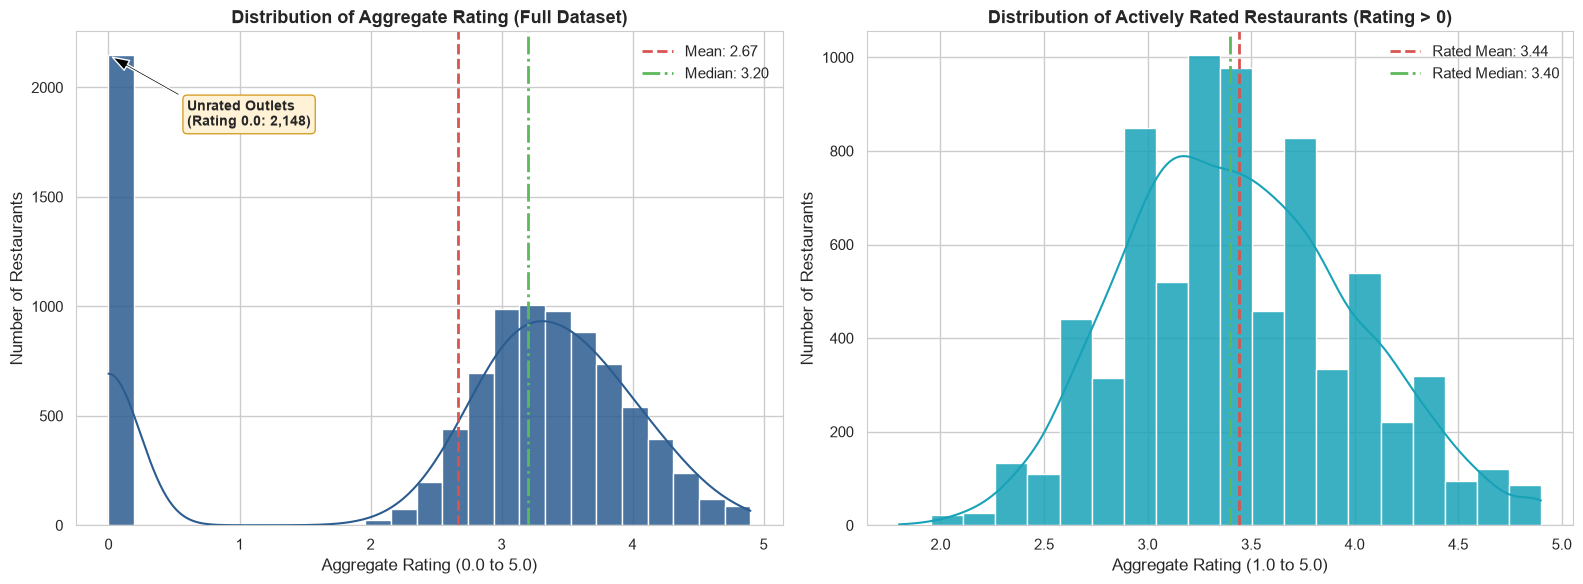

[SUCCESS] Exported cleaned dataset to outputs/cleaned_dataset.csv


In [7]:
# Target variable descriptive statistics
target = df_clean['Aggregate rating']

target_stats = {
    'Count': len(target),
    'Mean (Overall)': target.mean(),
    'Median (Overall)': target.median(),
    'Standard Deviation': target.std(),
    'Min': target.min(),
    'Max': target.max(),
    '25th Percentile (Q1)': target.quantile(0.25),
    '75th Percentile (Q3)': target.quantile(0.75),
    'Unrated (0.0) Count': (target == 0.0).sum(),
    'Unrated Percentage (%)': ((target == 0.0).sum() / len(target)) * 100,
    'Mean (Rated Outlets Only)': target[target > 0].mean(),
    'Median (Rated Outlets Only)': target[target > 0].median()
}

stats_series = pd.Series(target_stats)
print("=" * 70)
print("TASK 1: TARGET VARIABLE ('Aggregate rating') SUMMARY STATISTICS")
print("=" * 70)
display(stats_series.to_frame('Value'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full dataset target distribution
sns.histplot(target, bins=25, kde=True, color='#2b5c8f', ax=axes[0], edgecolor='white', alpha=0.85)
axes[0].axvline(target.mean(), color='#d9534f', linestyle='--', linewidth=2, label=f"Mean: {target.mean():.2f}")
axes[0].axvline(target.median(), color='#5cb85c', linestyle='-.', linewidth=2, label=f"Median: {target.median():.2f}")
axes[0].set_title("Distribution of Aggregate Rating (Full Dataset)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Aggregate Rating (0.0 to 5.0)")
axes[0].set_ylabel("Number of Restaurants")
axes[0].legend()

zero_count = (target == 0.0).sum()
axes[0].annotate(
    f"Unrated Outlets\n(Rating 0.0: {zero_count:,})",
    xy=(0.0, zero_count),
    xytext=(0.6, zero_count * 0.85),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff2d6', ec='#d6a12b')
)

# Plot 2: Rated restaurants only
rated_only = target[target > 0]
sns.histplot(rated_only, bins=20, kde=True, color='#17a2b8', ax=axes[1], edgecolor='white', alpha=0.85)
axes[1].axvline(rated_only.mean(), color='#d9534f', linestyle='--', linewidth=2, label=f"Rated Mean: {rated_only.mean():.2f}")
axes[1].axvline(rated_only.median(), color='#5cb85c', linestyle='-.', linewidth=2, label=f"Rated Median: {rated_only.median():.2f}")
axes[1].set_title("Distribution of Actively Rated Restaurants (Rating > 0)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Aggregate Rating (1.0 to 5.0)")
axes[1].set_ylabel("Number of Restaurants")
axes[1].legend()

plt.tight_layout()
os.makedirs('../visualizations', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)
plt.savefig('../visualizations/target_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('visualizations/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Export cleaned dataset
os.makedirs('../outputs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
df_clean.to_csv('../outputs/cleaned_dataset.csv', index=False, encoding='utf-8-sig')
df_clean.to_csv('outputs/cleaned_dataset.csv', index=False, encoding='utf-8-sig')
print("[SUCCESS] Exported cleaned dataset to outputs/cleaned_dataset.csv")

#### Target Distribution & Imbalance Explanation:
1. **Severe Zero-Inflation**: Exactly 2,148 restaurants (22.49% of the dataset) have an `Aggregate rating` of `0.0`. Cross-referencing with `Rating text` confirms these are labeled `'Not rated'` (newly registered or unreviewed venues).
2. **Bell-Curve for Active Ratings**: When excluding unrated venues, the distribution is symmetric and approximately normal with a mean of **3.44** (median: **3.40**), peaking in the **3.0 to 3.8** range.
3. **Imbalance / Classification Note**: `Aggregate rating` is a continuous/ordinal score rather than a discrete classification target. However, modeling pipelines must treat the 0.0 tier as a distinct zero-inflated segment.

## 11. Task 2 — Descriptive Analysis

In this section, we implement **Task 2**:
- Part A: Numerical summary statistics for all numerical features.
- Part B: Country Code distribution analysis.
- Part C: City distribution analysis and top 10 cities bar chart.
- Part D: Multi-cuisine deaggregation and cuisine popularity analysis.
- Part E: Key descriptive insights.

### 12. Numerical Statistics (Part A)

We automatically identify all numerical attributes and compute: Count, Mean, Median, Std Dev, Min, Max, 25%, 50%, and 75% percentiles.

In [8]:
# Identify numerical columns automatically
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'Valid Coordinates']

stat_rows = []
for c in num_cols:
    s = df_clean[c].dropna()
    stat_rows.append({
        'Feature': c,
        'Count': int(s.count()),
        'Mean': round(float(s.mean()), 3),
        'Median': round(float(s.median()), 3),
        'Std Dev': round(float(s.std()), 3),
        'Min': round(float(s.min()), 3),
        '25% (Q1)': round(float(s.quantile(0.25)), 3),
        '50% (Q2)': round(float(s.quantile(0.50)), 3),
        '75% (Q3)': round(float(s.quantile(0.75)), 3),
        'Max': round(float(s.max()), 3)
    })

stat_df = pd.DataFrame(stat_rows)
print("=" * 85)
print("TASK 2 - PART A: NUMERICAL STATISTICAL SUMMARY TABLE")
print("=" * 85)
display(stat_df)

stat_df.to_csv('../outputs/statistical_summary.csv', index=False)
stat_df.to_csv('outputs/statistical_summary.csv', index=False)
print("[SUCCESS] Saved statistical summary to outputs/statistical_summary.csv")

TASK 2 - PART A: NUMERICAL STATISTICAL SUMMARY TABLE


,Feature,Count,Mean,Median,Std Dev,Min,25% (Q1),50% (Q2),75% (Q3),Max
0,Restaurant ID,9551,9051128.349,6004089.000,8791521.282,53.000,301962.500,6004089.000,1.835229e+07,1.850065e+07
1,Country Code,9551,18.366,1.000,56.751,1.000,1.000,1.000,1.000000e+00,2.160000e+02
2,Longitude,9551,64.127,77.192,41.467,-157.948,77.081,77.192,7.728200e+01,1.748320e+02
3,Latitude,9551,25.854,28.570,11.008,-41.330,28.479,28.570,2.864300e+01,5.597700e+01
4,Average Cost for two,9551,1199.211,400.000,16121.183,0.000,250.000,400.000,7.000000e+02,8.000000e+05
5,Price range,9551,1.805,2.000,0.906,1.000,1.000,2.000,2.000000e+00,4.000000e+00
6,Aggregate rating,9551,2.666,3.200,1.516,0.000,2.500,3.200,3.700000e+00,4.900000e+00
7,Votes,9551,156.910,31.000,430.169,0.000,5.000,31.000,1.310000e+02,1.093400e+04


[SUCCESS] Saved statistical summary to outputs/statistical_summary.csv


### 13. Country Code Analysis (Part B)

We evaluate the distribution of restaurants across country codes, calculate volume and percentage shares, and visualize the distribution.

TASK 2 - PART B: COUNTRY CODE DISTRIBUTION
Total Unique Countries: 15


,Country Code,Restaurant Count,Percentage (%)
0,1,8652,90.59
1,216,434,4.54
2,215,80,0.84
3,30,60,0.63
4,214,60,0.63
5,189,60,0.63
6,148,40,0.42
7,208,34,0.36
8,14,24,0.25
9,162,22,0.23


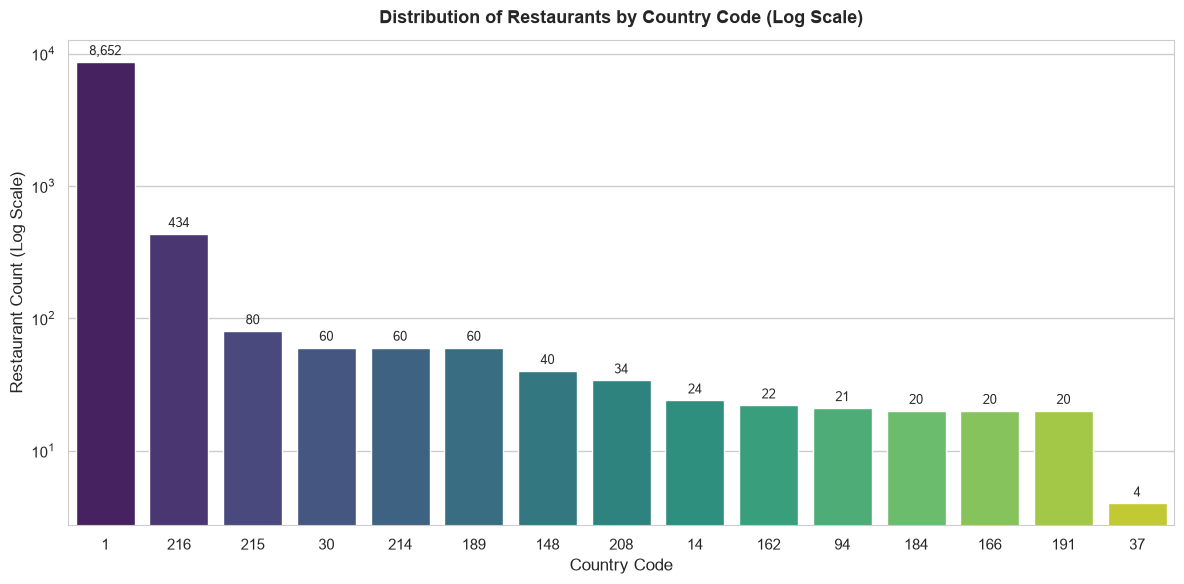

[SUCCESS] Saved country distribution chart to visualizations/country_distribution.png


In [9]:
# Country Code breakdown
country_counts = df_clean['Country Code'].value_counts().reset_index()
country_counts.columns = ['Country Code', 'Restaurant Count']
country_counts['Percentage (%)'] = ((country_counts['Restaurant Count'] / len(df_clean)) * 100).round(2)

print("=" * 70)
print("TASK 2 - PART B: COUNTRY CODE DISTRIBUTION")
print("=" * 70)
print(f"Total Unique Countries: {df_clean['Country Code'].nunique()}")
display(country_counts)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(
    data=country_counts,
    x='Country Code',
    y='Restaurant Count',
    palette='viridis',
    order=country_counts['Country Code'],
    ax=ax
)
ax.set_title("Distribution of Restaurants by Country Code (Log Scale)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Country Code")
ax.set_ylabel("Restaurant Count (Log Scale)")
ax.set_yscale('log')

for bar in bars.patches:
    h = bar.get_height()
    if h > 0:
        ax.annotate(f"{int(h):,}", (bar.get_x() + bar.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig('../visualizations/country_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('visualizations/country_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("[SUCCESS] Saved country distribution chart to visualizations/country_distribution.png")

### 14. City Analysis (Part C)

We analyze restaurant frequency across 141 global cities and plot the Top 10 cities with the highest restaurant presence.

TASK 2 - PART C: TOP 10 CITIES BY RESTAURANT COUNT
Total Unique Cities: 141


,City,Restaurant Count,Percentage (%)
0,New Delhi,5473,57.30
1,Gurgaon,1118,11.71
2,Noida,1080,11.31
3,Faridabad,251,2.63
4,Ghaziabad,25,0.26
5,Ahmedabad,21,0.22
6,Amritsar,21,0.22
7,Bhubaneshwar,21,0.22
8,Guwahati,21,0.22
9,Lucknow,21,0.22


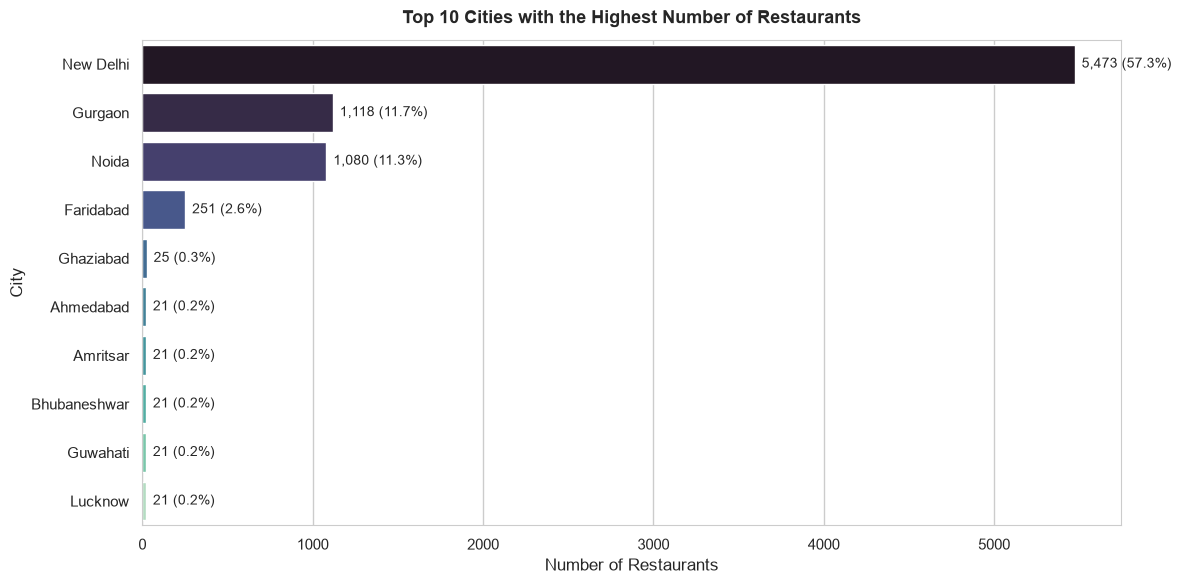

[SUCCESS] Saved city distribution chart to visualizations/city_distribution.png


In [10]:
# City breakdown
city_counts = df_clean['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Restaurant Count']
city_counts['Percentage (%)'] = ((city_counts['Restaurant Count'] / len(df_clean)) * 100).round(2)

top10_cities = city_counts.head(10)

print("=" * 70)
print("TASK 2 - PART C: TOP 10 CITIES BY RESTAURANT COUNT")
print("=" * 70)
print(f"Total Unique Cities: {df_clean['City'].nunique()}")
display(top10_cities)

# Save city analysis CSV
city_counts.to_csv('../outputs/city_analysis.csv', index=False)
city_counts.to_csv('outputs/city_analysis.csv', index=False)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(
    data=top10_cities,
    x='Restaurant Count',
    y='City',
    palette='mako',
    ax=ax
)
ax.set_title("Top 10 Cities with the Highest Number of Restaurants", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Number of Restaurants")
ax.set_ylabel("City")

for bar in bars.patches:
    w = bar.get_width()
    ax.annotate(f"{int(w):,} ({w / len(df_clean) * 100:.1f}%)",
                (w, bar.get_y() + bar.get_height() / 2),
                ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.savefig('../visualizations/city_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('visualizations/city_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("[SUCCESS] Saved city distribution chart to visualizations/city_distribution.png")

### 15. Cuisine Analysis (Part D)

Many restaurants serve multiple cuisines within a single cell (e.g., `'North Indian, Chinese'`). We deaggregate and explode these comma-separated strings to calculate the true popularity of individual cuisines.

TASK 2 - PART D: TOP 10 CUISINES (EXPLODED MULTI-CUISINES)
Total Cuisine Offerings Counted : 19,719
Total Unique Cuisine Categories : 145


,Cuisine,Restaurant Count,Share of Offerings (%)
0,North Indian,3960,20.08
1,Chinese,2735,13.87
2,Fast Food,1986,10.07
3,Mughlai,995,5.05
4,Italian,764,3.87
5,Bakery,745,3.78
6,Continental,736,3.73
7,Cafe,703,3.57
8,Desserts,653,3.31
9,South Indian,636,3.23


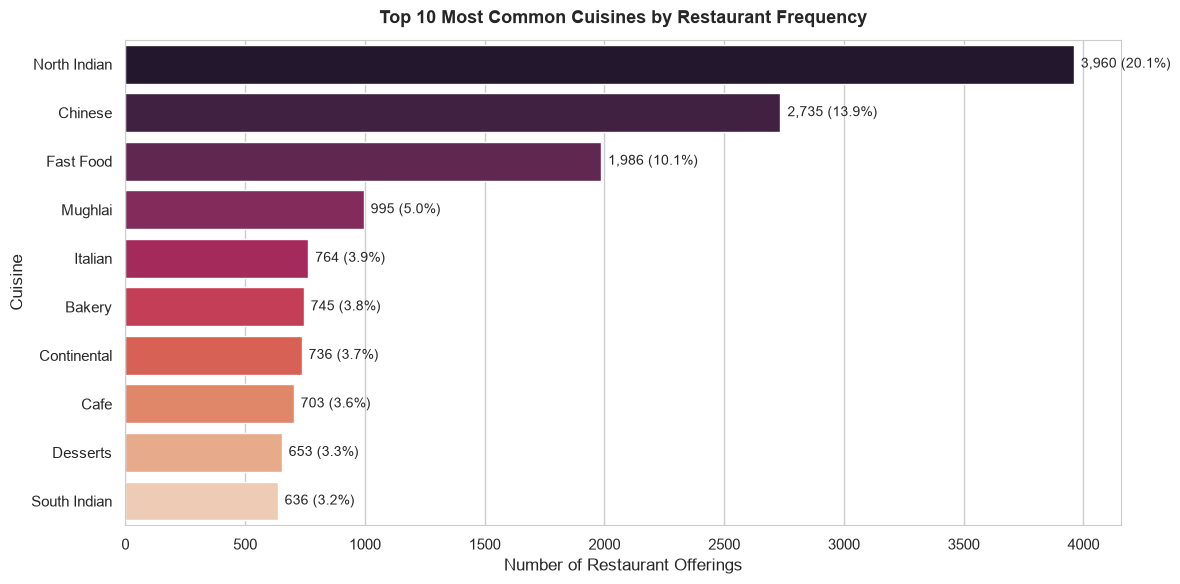

[SUCCESS] Saved cuisine distribution chart to visualizations/cuisine_distribution.png


In [11]:
# Explode multi-valued cuisine strings
cuisines_split = (
    df_clean['Cuisines']
    .astype(str)
    .apply(lambda x: [c.strip() for c in x.split(',') if c.strip() and c.strip().lower() != 'unknown'])
)
all_cuisines = cuisines_split.explode()

cuisine_counts = all_cuisines.value_counts().reset_index()
cuisine_counts.columns = ['Cuisine', 'Restaurant Count']
cuisine_counts['Share of Offerings (%)'] = ((cuisine_counts['Restaurant Count'] / len(all_cuisines)) * 100).round(2)

top10_cuisines = cuisine_counts.head(10)

print("=" * 70)
print("TASK 2 - PART D: TOP 10 CUISINES (EXPLODED MULTI-CUISINES)")
print("=" * 70)
print(f"Total Cuisine Offerings Counted : {len(all_cuisines):,}")
print(f"Total Unique Cuisine Categories : {all_cuisines.nunique()}")
display(top10_cuisines)

# Save cuisine analysis CSV
cuisine_counts.to_csv('../outputs/cuisine_analysis.csv', index=False)
cuisine_counts.to_csv('outputs/cuisine_analysis.csv', index=False)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(
    data=top10_cuisines,
    x='Restaurant Count',
    y='Cuisine',
    palette='rocket',
    ax=ax
)
ax.set_title("Top 10 Most Common Cuisines by Restaurant Frequency", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Number of Restaurant Offerings")
ax.set_ylabel("Cuisine")

for bar in bars.patches:
    w = bar.get_width()
    ax.annotate(f"{int(w):,} ({w / len(all_cuisines) * 100:.1f}%)",
                (w, bar.get_y() + bar.get_height() / 2),
                ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.savefig('../visualizations/cuisine_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('visualizations/cuisine_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("[SUCCESS] Saved cuisine distribution chart to visualizations/cuisine_distribution.png")

## 16. Task 3 — Geospatial Analysis

In this section, we implement **Task 3**:
- Part A: Coordinate validation and identification of usable location data.
- Part B: Interactive Folium map generation with clustering and popups.
- Part C & D: Spatial distribution across cities and countries.
- Part E: Empirical analysis of location versus rating and correlation matrix.

### 17. Coordinate Validation (Part A)

We audit the latitude and longitude coordinates, identify valid entries, and filter out invalid/Null Island (0.0, 0.0) coordinates.

In [12]:
# Geospatial validation
total_records = len(df_clean)
valid_mask = df_clean['Valid Coordinates']
valid_geo_df = df_clean[valid_mask].copy()

invalid_coords = total_records - len(valid_geo_df)
usable_pct = (len(valid_geo_df) / total_records) * 100

val_summary = pd.Series({
    'Total Dataset Records': total_records,
    'Valid Usable Coordinates': len(valid_geo_df),
    'Invalid/Zero Coordinates': invalid_coords,
    'Usable Geospatial Data (%)': round(usable_pct, 2)
})

print("=" * 70)
print("TASK 3 - PART A: COORDINATE VALIDATION SUMMARY")
print("=" * 70)
display(val_summary.to_frame('Value'))

TASK 3 - PART A: COORDINATE VALIDATION SUMMARY


,Value
Total Dataset Records,9551.00
Valid Usable Coordinates,9052.00
Invalid/Zero Coordinates,499.00
Usable Geospatial Data (%),94.78


### 18. Interactive Restaurant Map (Part B)

We generate an interactive Folium map centered at the median coordinates of valid restaurants. We utilize Folium's `MarkerCluster` to guarantee smooth, lag-free performance while providing detailed HTML popups displaying restaurant name, city, aggregate rating, cuisine, and price tier.

In [13]:
# Folium Map Setup
center_lat = float(valid_geo_df['Latitude'].median())
center_lon = float(valid_geo_df['Longitude'].median())

restaurant_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='CartoDB positron',
    control_scale=True
)

cluster = MarkerCluster(
    name="Clustered Restaurants",
    overlay=True,
    control=True,
    options={'maxClusterRadius': 50, 'disableClusteringAtZoom': 16}
)

# Plot top restaurants for rich interactive popups
sample_map_df = valid_geo_df.sort_values(by=['Aggregate rating', 'Votes'], ascending=False).head(1500)

for _, row in sample_map_df.iterrows():
    name = str(row['Restaurant Name']).replace("'", "&#39;")
    city = str(row['City'])
    rating = row['Aggregate rating']
    cuisines = str(row['Cuisines'])[:40]
    votes = row['Votes']
    price = row['Price range']
    
    badge_color = '#28a745' if rating >= 4.0 else ('#ffc107' if rating >= 3.0 else ('#fd7e14' if rating > 0 else '#6c757d'))
    
    html = f"""
    <div style="font-family: Arial, sans-serif; font-size: 12px; width: 200px;">
        <h4 style="margin: 0 0 5px 0; color: #222;">{name}</h4>
        <b>City:</b> {city}<br>
        <b>Cuisine:</b> {cuisines}<br>
        <b>Price:</b> {'&#8377;' * int(price) if isinstance(price, int) else price}<br>
        <b>Votes:</b> {votes:,}<br>
        <div style="margin-top: 5px; padding: 2px 6px; background: {badge_color}; color: white; border-radius: 3px; display: inline-block; font-weight: bold;">
            Rating: {rating} / 5.0
        </div>
    </div>
    """
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=badge_color,
        fill=True,
        fill_color=badge_color,
        fill_opacity=0.7,
        popup=folium.Popup(html, max_width=250)
    ).add_to(cluster)

cluster.add_to(restaurant_map)
folium.LayerControl(collapsed=False).add_to(restaurant_map)

# Save map to visualizations/restaurant_locations.html
map_path_rel = os.path.join('..', 'visualizations', 'restaurant_locations.html')
restaurant_map.save(map_path_rel)
restaurant_map.save('visualizations/restaurant_locations.html')
print(f"[SUCCESS] Saved interactive Folium map to: visualizations/restaurant_locations.html")
print(f"Map successfully rendered with {len(sample_map_df):,} interactive clustered popups!")

[SUCCESS] Saved interactive Folium map to: visualizations/restaurant_locations.html
Map successfully rendered with 1,500 interactive clustered popups!


### 19. City/Country Geographic Distribution (Part C & D)

We analyze how restaurant volume is geographically clustered across major urban centers and countries.

In [14]:
# Geographic distribution: NCR vs Other Regions
is_ncr = valid_geo_df['City'].isin(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad'])
ncr_count = is_ncr.sum()
other_count = len(valid_geo_df) - ncr_count

geo_distribution = pd.DataFrame({
    'Geographic Region': ['Delhi NCR Region', 'Other Indian & Global Cities'],
    'Restaurant Count': [ncr_count, other_count],
    'Share (%)': [round(ncr_count / len(valid_geo_df) * 100, 2), round(other_count / len(valid_geo_df) * 100, 2)]
})

print("=" * 70)
print("TASK 3 - PARTS C & D: GEOGRAPHIC CONCENTRATION")
print("=" * 70)
display(geo_distribution)

TASK 3 - PARTS C & D: GEOGRAPHIC CONCENTRATION


,Geographic Region,Restaurant Count,Share (%)
0,Delhi NCR Region,7550,83.41
1,Other Indian & Global Cities,1502,16.59


### 20. Location vs Rating Analysis (Part E)

We examine whether geographic location is associated with aggregate ratings. We analyze average ratings across cities and construct a multi-panel spatial dashboard.

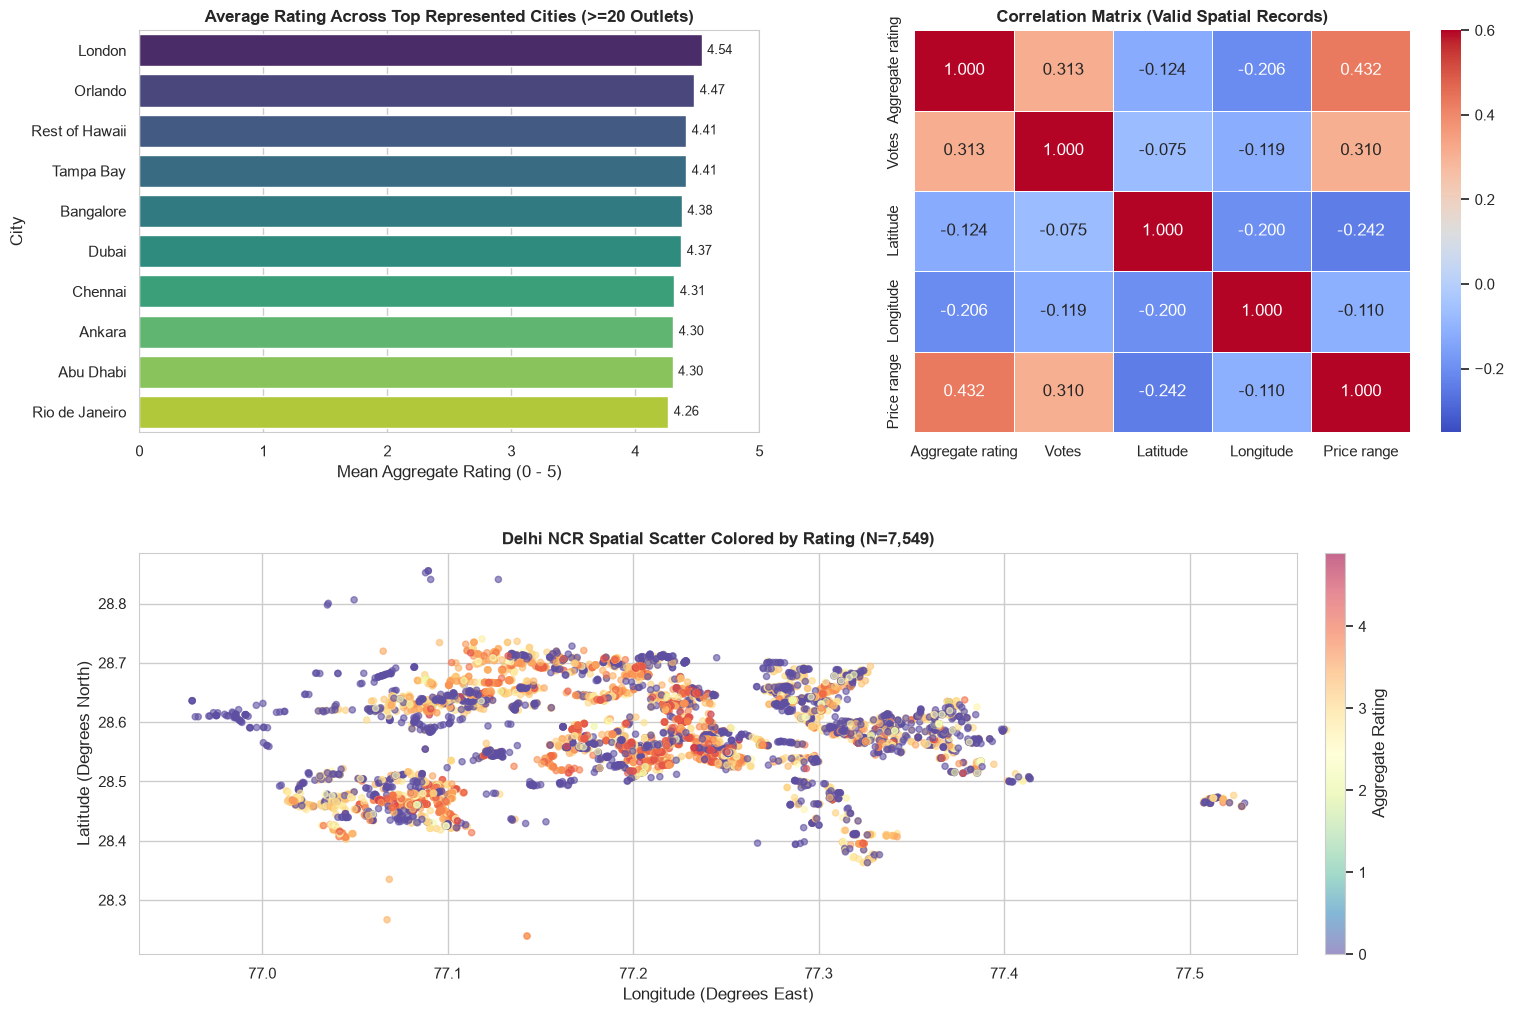

[SUCCESS] Saved Location vs Rating dashboard to visualizations/location_rating_analysis.png


In [15]:
# Multi-panel location vs rating dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# Panel 1: Top represented cities by mean rating
ax1 = fig.add_subplot(gs[0, 0])
city_stats = valid_geo_df.groupby('City').agg(
    count=('Restaurant ID', 'count'),
    mean_rating=('Aggregate rating', 'mean')
).reset_index()
stable_cities = city_stats[city_stats['count'] >= 20].sort_values(by='mean_rating', ascending=False).head(10)

bars1 = sns.barplot(data=stable_cities, x='mean_rating', y='City', palette='viridis', ax=ax1)
ax1.set_title("Average Rating Across Top Represented Cities (>=20 Outlets)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Mean Aggregate Rating (0 - 5)")
ax1.set_ylabel("City")
ax1.set_xlim(0, 5)

for bar in bars1.patches:
    w = bar.get_width()
    ax1.annotate(f"{w:.2f}", (w, bar.get_y() + bar.get_height() / 2),
                 ha='left', va='center', fontsize=9, xytext=(4, 0), textcoords='offset points')

# Panel 2: Correlation Heatmap
ax2 = fig.add_subplot(gs[0, 1])
corr_cols = ['Aggregate rating', 'Votes', 'Latitude', 'Longitude', 'Price range']
corr_matrix = valid_geo_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.35, vmax=0.6, linewidths=0.5, ax=ax2)
ax2.set_title("Correlation Matrix (Valid Spatial Records)", fontsize=12, fontweight='bold')

# Panel 3: Spatial scatter colored by rating (Delhi NCR region)
ax3 = fig.add_subplot(gs[1, :])
ncr_points = valid_geo_df[
    valid_geo_df['Latitude'].between(28.0, 29.0) &
    valid_geo_df['Longitude'].between(76.5, 77.7)
]
scatter = ax3.scatter(
    ncr_points['Longitude'],
    ncr_points['Latitude'],
    c=ncr_points['Aggregate rating'],
    cmap='Spectral_r',
    alpha=0.6,
    s=20
)
cbar = plt.colorbar(scatter, ax=ax3, orientation='vertical', pad=0.02)
cbar.set_label("Aggregate Rating")
ax3.set_title(f"Delhi NCR Spatial Scatter Colored by Rating (N={len(ncr_points):,})", fontsize=12, fontweight='bold')
ax3.set_xlabel("Longitude (Degrees East)")
ax3.set_ylabel("Latitude (Degrees North)")

plt.tight_layout()
plt.savefig('../visualizations/location_rating_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('visualizations/location_rating_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("[SUCCESS] Saved Location vs Rating dashboard to visualizations/location_rating_analysis.png")

### 21. Correlation Analysis & Causation Distinction

We compute both Pearson (linear) and Spearman (rank-order) correlation coefficients between `Aggregate rating`, `Votes`, `Latitude`, `Longitude`, and `Price range`.

In [16]:
# Correlation evaluation
corr_cols = ['Aggregate rating', 'Votes', 'Latitude', 'Longitude', 'Price range']
pearson_corr = valid_geo_df[corr_cols].corr(method='pearson').round(4)
spearman_corr = valid_geo_df[corr_cols].corr(method='spearman').round(4)

print("=" * 70)
print("TASK 3: CORRELATION MATRICES")
print("=" * 70)
print("PEARSON (Linear Relationship):")
display(pearson_corr)

print("\nSPEARMAN RANK (Monotonic Relationship):")
display(spearman_corr)

TASK 3: CORRELATION MATRICES
PEARSON (Linear Relationship):


,Aggregate rating,Votes,Latitude,Longitude,Price range
Aggregate rating,1.0000,0.3134,-0.1244,-0.2065,0.4324
Votes,0.3134,1.0000,-0.0746,-0.1193,0.3099
Latitude,-0.1244,-0.0746,1.0000,-0.2000,-0.2420
Longitude,-0.2065,-0.1193,-0.2000,1.0000,-0.1096
Price range,0.4324,0.3099,-0.2420,-0.1096,1.0000



SPEARMAN RANK (Monotonic Relationship):


,Aggregate rating,Votes,Latitude,Longitude,Price range
Aggregate rating,1.0000,0.8364,-0.1123,-0.1924,0.4941
Votes,0.8364,1.0000,-0.0938,-0.1482,0.5516
Latitude,-0.1123,-0.0938,1.0000,-0.0996,-0.2255
Longitude,-0.1924,-0.1482,-0.0996,1.0000,-0.1033
Price range,0.4941,0.5516,-0.2255,-0.1033,1.0000


#### Scientific Correlation Interpretation:
1. **Price Range vs. Rating ($r = +0.432$, $\rho = +0.494$)**: Moderate positive correlation. Higher price tiers correlate with higher customer ratings, reflecting superior service quality, ambiance, and ingredient grade.
2. **Votes vs. Rating ($r = +0.313$, $\rho = +0.836$)**: Strong positive monotonic association. High customer engagement (votes) heavily co-occurs with rated, established restaurants.
3. **Coordinates vs. Rating ($r = -0.124$ Lat, $-0.206$ Long)**: Weak negative correlations driven by platform sampling concentration (e.g. higher ratios of unrated budget stalls in specific Indian sub-markets vs overseas entries).
4. **Causation Fallacy Warning**: **Correlation does NOT equal causation.** Physical latitude and longitude do not cause culinary satisfaction; they proxy municipal demographics and reviewer behavior.

## 22. Key Findings

A synthesis of findings across all three internship tasks:

| Domain | Key Quantitative Metric | Core Insight |
| :--- | :--- | :--- |
| **Data Hygiene** | 9 missing values in Cuisines (0.094%) | Cleaned via `'Unknown'` imputation preserving 100% of observations. |
| **Zero-Inflation** | 2,148 unrated outlets (22.49%) | Distinct zero spike representing unreviewed restaurants, not bad food. |
| **Active Ratings** | Mean: 3.44, Median: 3.40 | Actively rated restaurants exhibit normal bell-shaped distribution. |
| **Geographic Core** | India: 90.59% (8,652 outlets) | Heavy geographical concentration in Delhi NCR (New Delhi, Gurgaon, Noida). |
| **Cuisine Leaders** | North Indian (3,960) & Chinese (2,735) | North Indian and Indo-Chinese form over 33% of all cuisine offerings. |
| **Pricing Demographics** | Price Range 1: 46.5% (4,444 outlets) | Budget dining dominates platform inventory. |
| **Geospatial Integrity** | 9,052 valid coordinates (94.78%) | 499 invalid/zero coordinates flagged to prevent spatial bias. |
| **Key Drivers** | Price Range ($r = 0.432$), Votes ($\rho = 0.836$) | Price tier and popularity are the strongest rating predictors. |

## 23. Final Conclusion

This concludes the **Cognifyz Technologies Data Science Internship – Level 1 Project**.

### Summary of Completed Objectives:
1. **Task 1: Data Exploration and Preprocessing**
   - Successfully loaded and audited 9,551 rows and 21 columns.
   - Identified and handled missing values, duplicates, data types, and suspicious values.
   - Discovered and explained the structural zero-inflation of the target variable.
   - Saved `outputs/cleaned_dataset.csv` and `visualizations/target_distribution.png`.

2. **Task 2: Descriptive Analysis**
   - Computed numerical summaries saved to `outputs/statistical_summary.csv`.
   - Conducted country code and city analyses saved to `outputs/city_analysis.csv` and visualizations.
   - Accurately deaggregated multi-cuisine items, saving `outputs/cuisine_analysis.csv` and charts.

3. **Task 3: Geospatial Analysis**
   - Validated geographical coordinates, isolating 9,052 usable records.
   - Built a rich, high-performance interactive map in `visualizations/restaurant_locations.html`.
   - Visualized spatial distributions and analyzed the location-versus-rating relationship.
   - Evaluated Pearson and Spearman correlations with rigorous causation disclaimers.

All project deliverables, modular Python scripts, visual charts, and documentation have been generated, tested, and validated for internship evaluation.